# Figure 1

![Full Figure](../figures/fig01_FULL.png)


## Code For Figure 1C–D: Fixation Growth Example Panels

**Goal:** Illustrate how fixation duration grows over consecutive trials during the early fixation-growth curriculum (stage ≥ 5), for one representative animal from each curriculum arm.

| Panel | Curriculum | Animal | Data source |
|-------|-----------|--------|-------------|
| C | Legacy | R042 | trial-level (`trials_df`) |
| D | FixGrower | R043 | poke-level (`poke_df`) |

**Outputs:** `figures/fig01c_legacy_fix_growth.png`, `figures/fig01d_fixgrower_fix_growth.png`



In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from fixation_grower import config
from fixation_grower.io import load_trials_df, load_poke_df
from fixation_grower.plotting import save_figure
from fixation_grower.transforms import compute_days_relative_to_stage

sns.set_context("talk")

In [14]:
# shared settings
MAX_DAYS = 4       # show first 4 days in stage 5
TARGET_S = 0.8    # reference fixation duration (seconds)
RELATIVE_TO_STAGE = 5  # stage 5 is where the curricula diverge

## Panel C — Legacy (R042)

Legacy is trial level data because each center poke starts a full trial (i.e. there is no retry)

In [15]:
tdf = load_trials_df()
tdf = compute_days_relative_to_stage(tdf, stage=RELATIVE_TO_STAGE)

PosixPath('/Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/figures/fig01c_legacy_fix_growth.png')

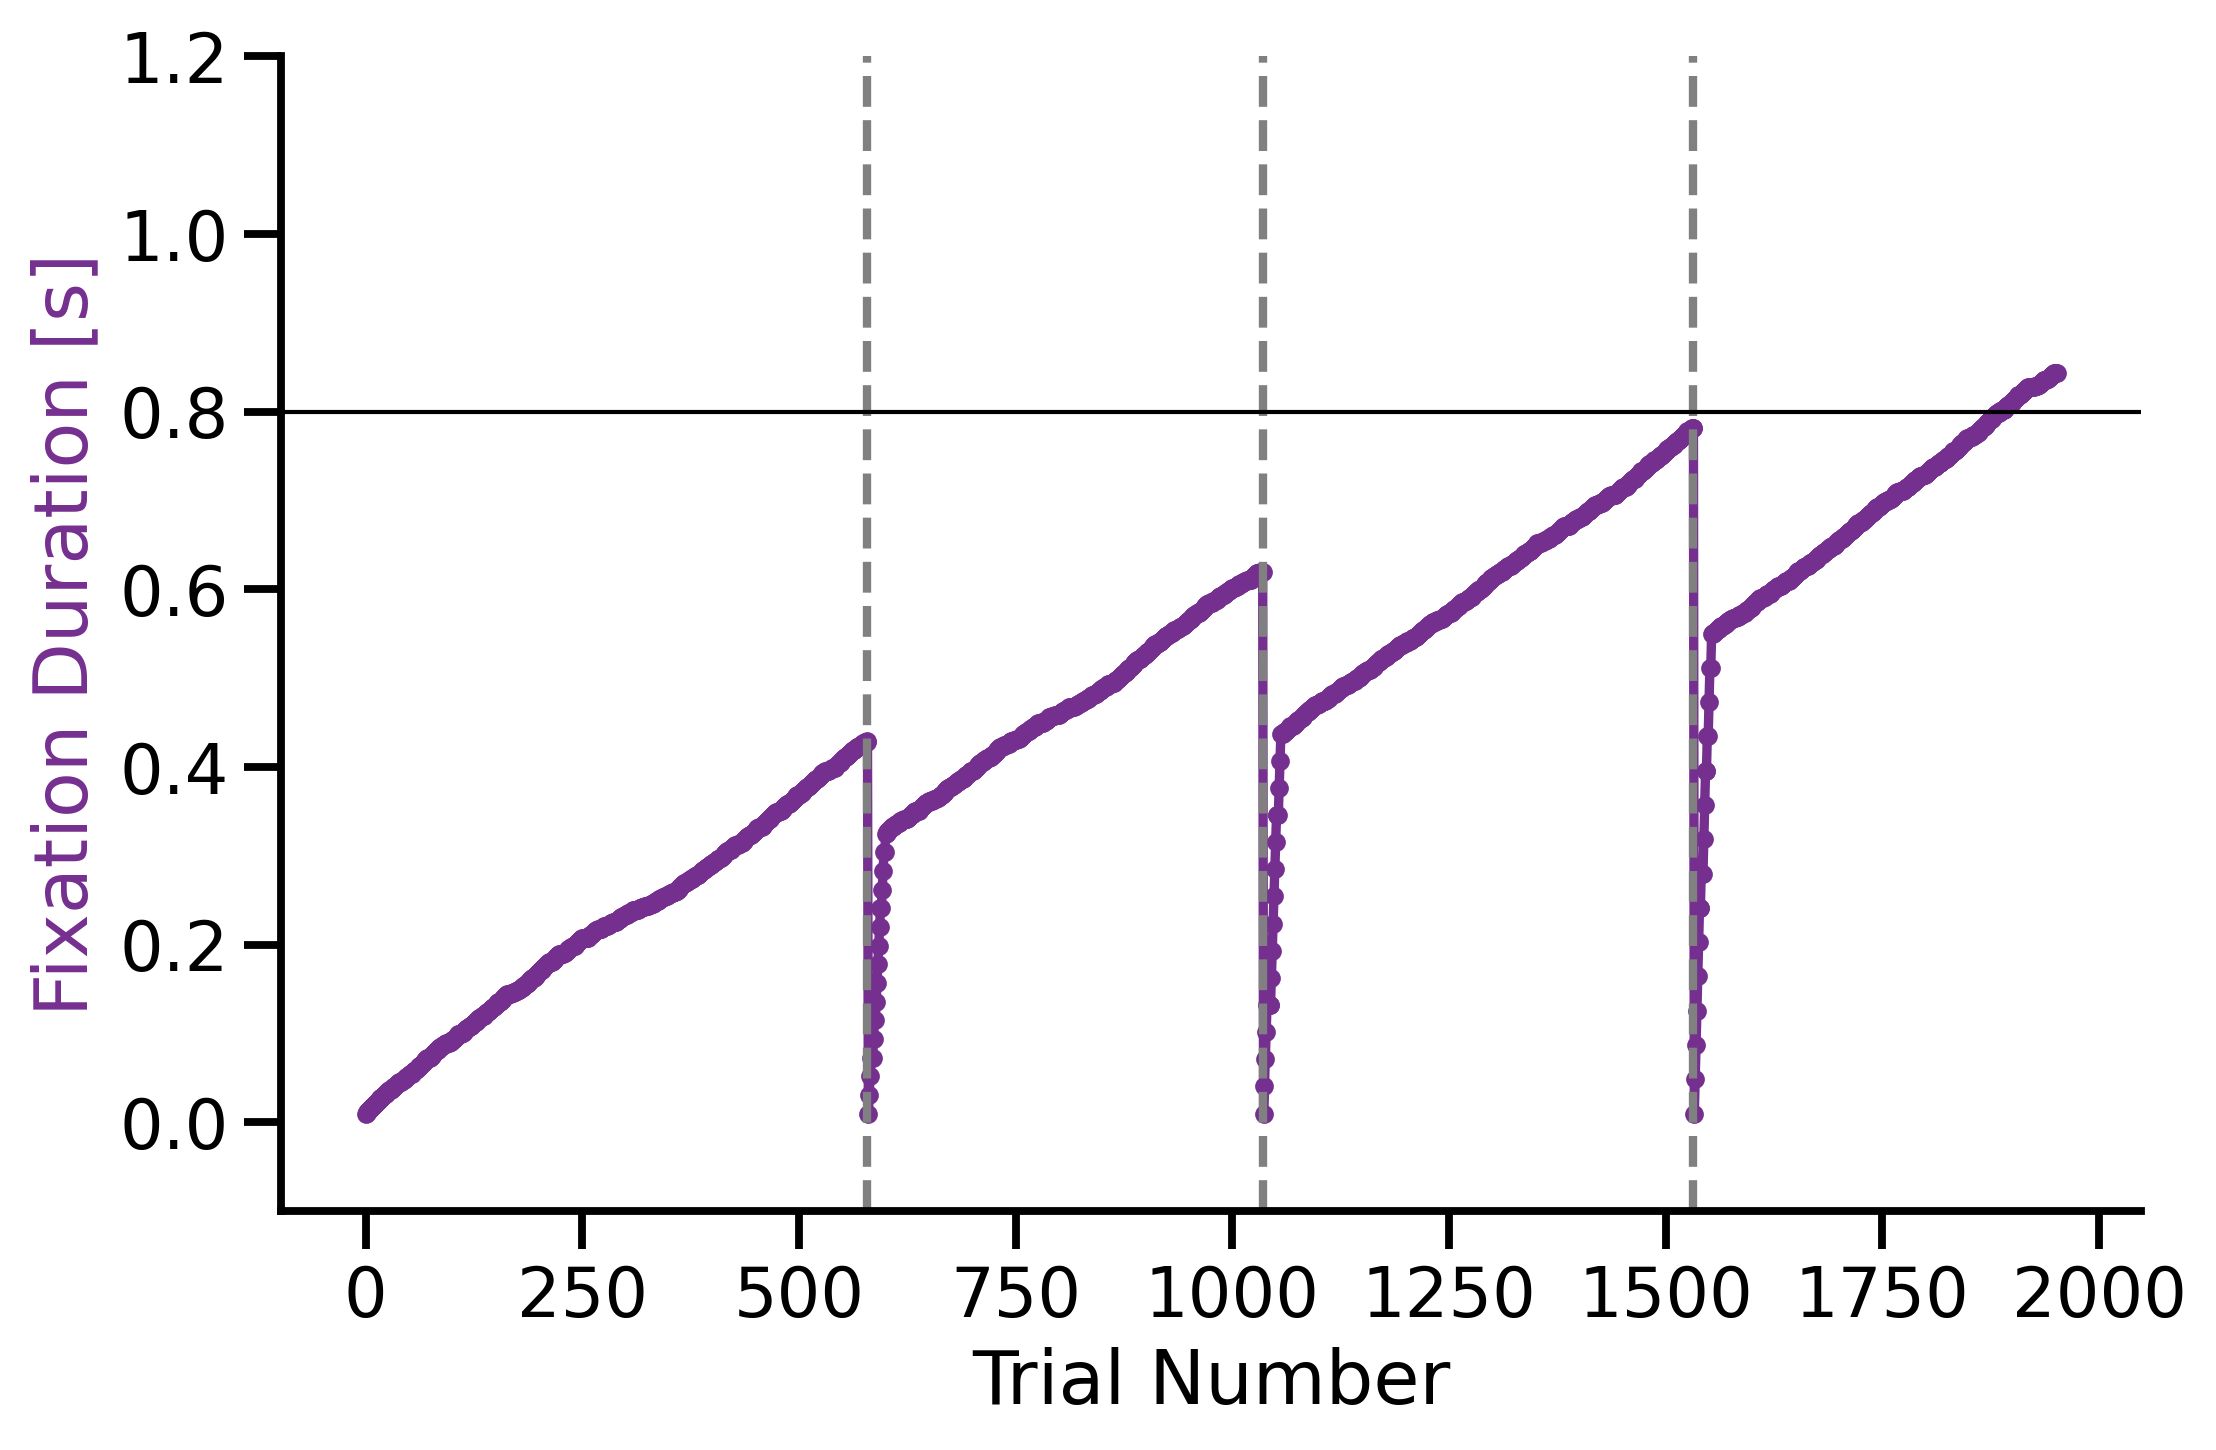

In [11]:

plot_df = (
    tdf.query("animal_id == @config.LEGACY_DEMO_ANIMAL and stage >= 5")
    .copy()
)
plot_df["total_trials"] = range(len(plot_df))
plot_df = plot_df.query("days_relative_to_stage_5 < @MAX_DAYS")

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

sns.lineplot(
    data=plot_df, x="total_trials", y="fixation_dur",
    color=config.LEGACY_COLOR, marker=".", markeredgecolor="none", ax=ax,
)

for start in plot_df.groupby("sess_id")["total_trials"].min() - 1:
    if start > 0:
        ax.axvline(x=start, color="gray", linestyle="--", lw=2)

ax.axhline(TARGET_S, color="black", lw=1)
ax.set(xlabel="Trial Number", ylim=(-0.1, 1.2))
ax.set_ylabel("Fixation Duration [s]", color=config.LEGACY_COLOR)
sns.despine(ax=ax)

save_figure(fig, "fig01c_legacy_fix_growth")

## Panel D — FixGrower (R043, poke-level data)

FixGrower animals are poke-level data because each trial is registered as a poke into the center port but the "trial" df only cleans up after a successful fixation.

In [16]:
pdf = load_poke_df()
pdf = compute_days_relative_to_stage(pdf, stage=RELATIVE_TO_STAGE)

PosixPath('/Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/figures/fig01d_fixgrower_fix_growth.png')

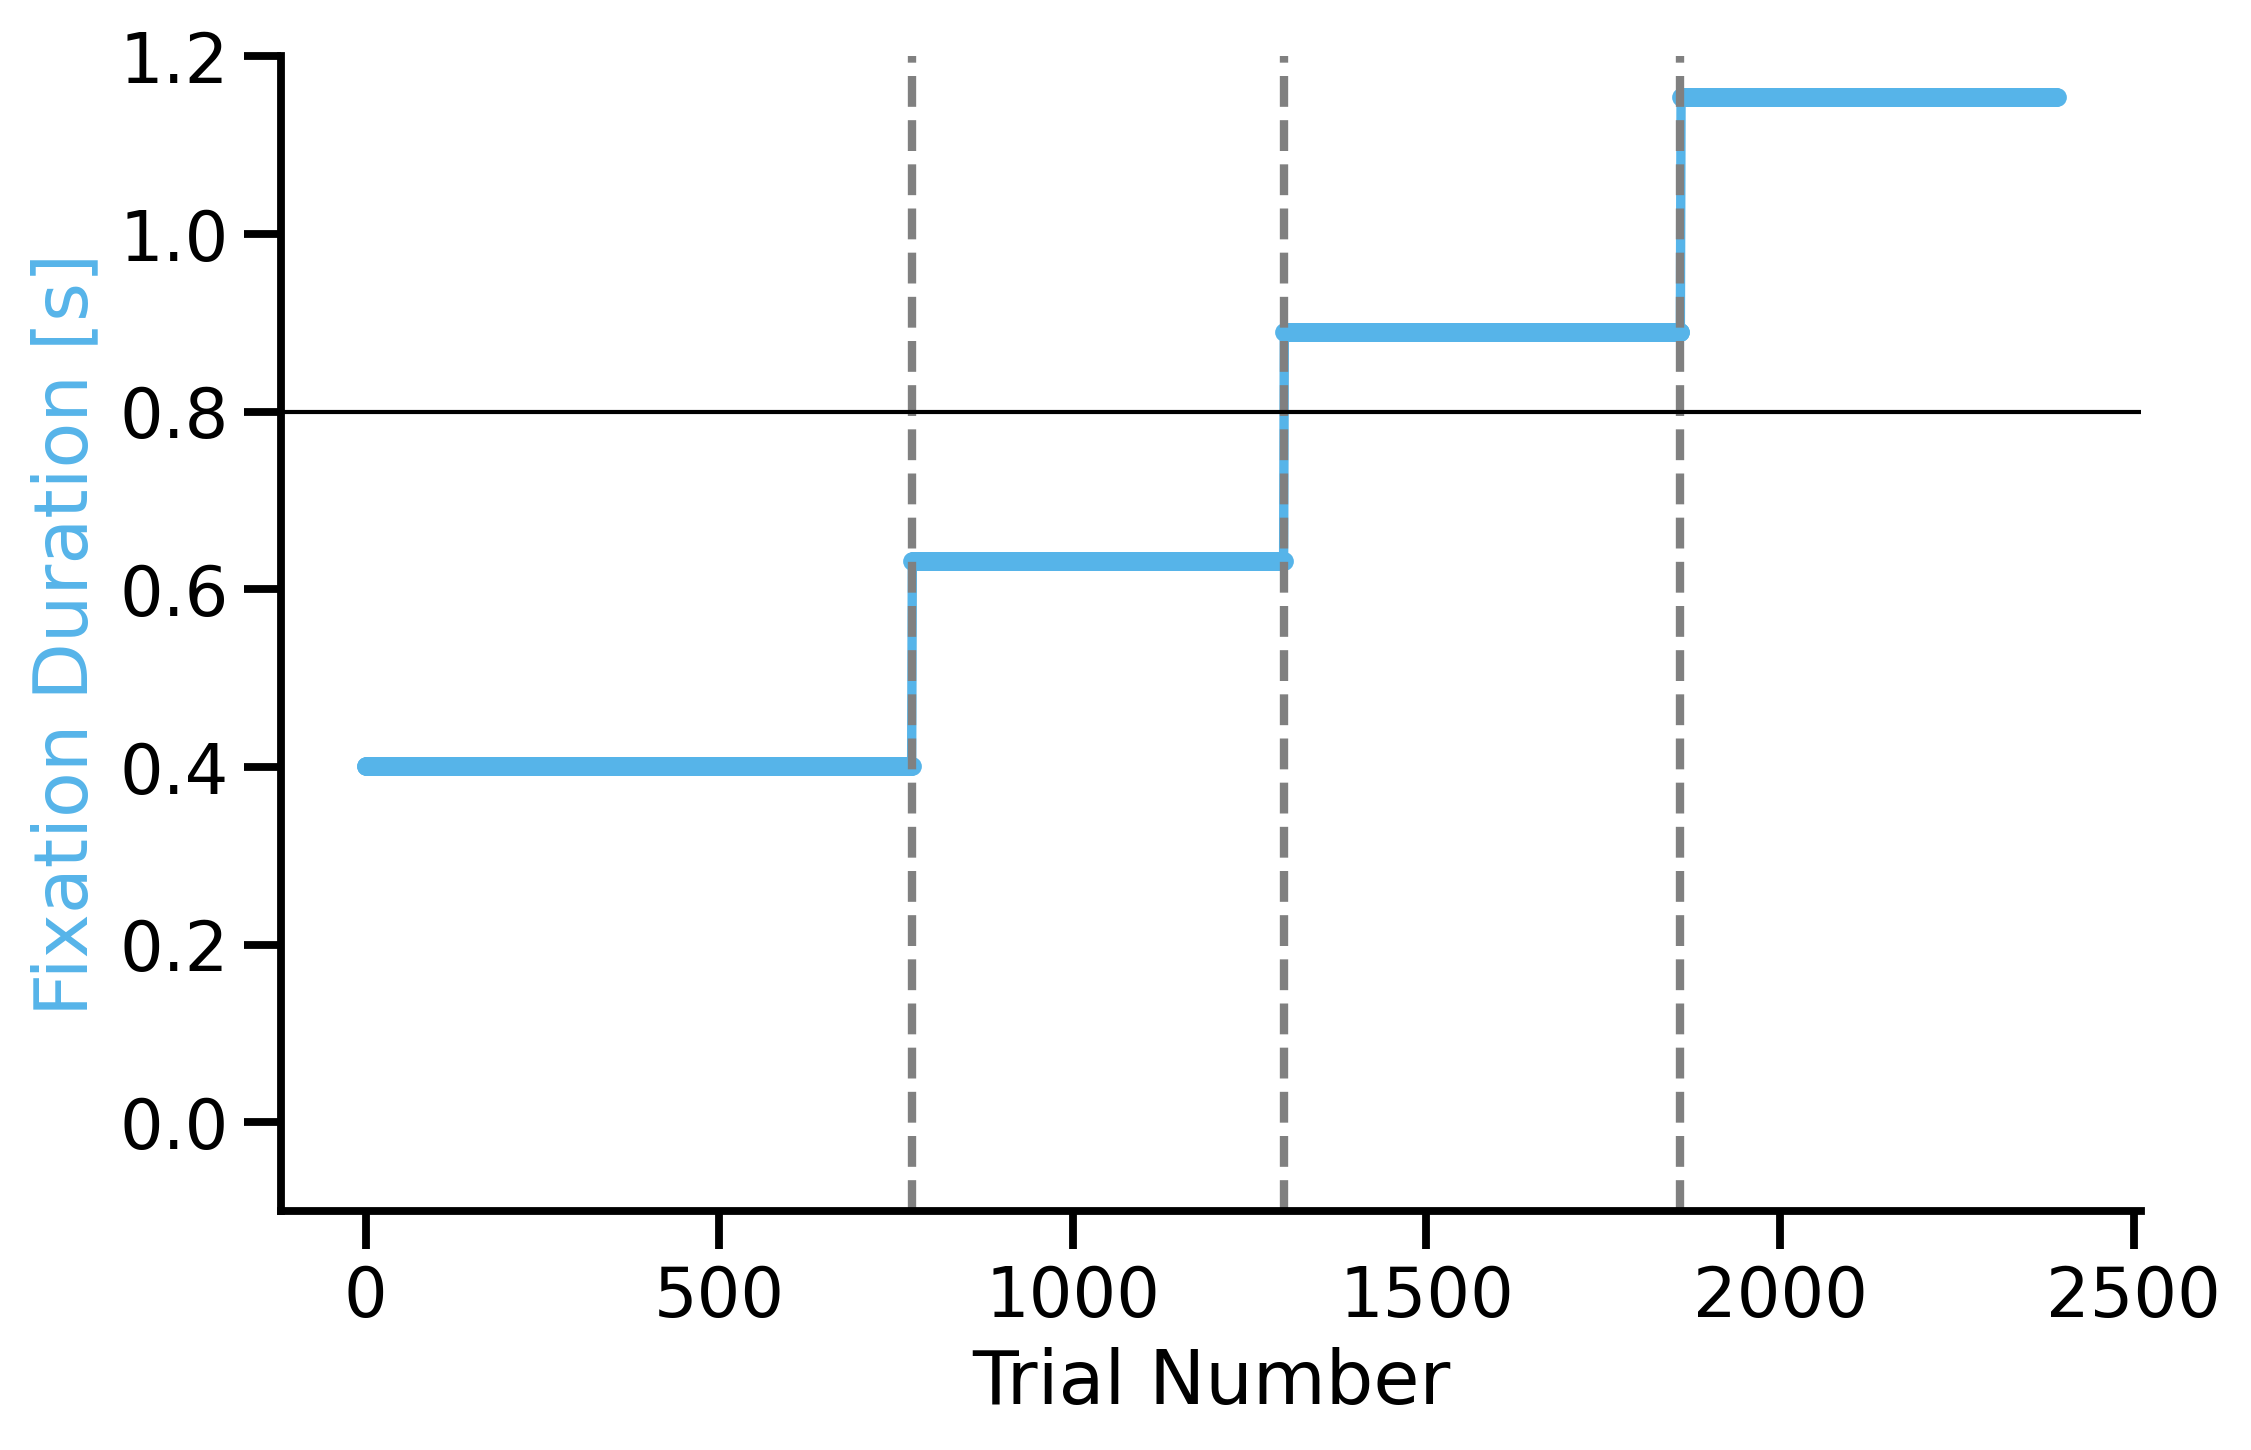

In [13]:
plot_df = (
    pdf.query("animal_id == @config.FIXGROWER_DEMO_ANIMAL and stage >= 5")
    .copy()
)
plot_df["total_trials"] = range(len(plot_df))
plot_df = plot_df.query("days_relative_to_stage_5 < @MAX_DAYS")

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

sns.lineplot(
    data=plot_df, x="total_trials", y="fixation_dur",
    color=config.FIXGROWER_COLOR, marker=".", markeredgecolor="none", ax=ax,
)

for start in plot_df.groupby("sessid")["total_trials"].min() - 1:
    if start > 0:
        ax.axvline(x=start, color="gray", linestyle="--", lw=2)

ax.axhline(TARGET_S, color="black", lw=1)
ax.set(xlabel="Trial Number", ylim=(-0.1, 1.2))
ax.set_ylabel("Fixation Duration [s]", color=config.FIXGROWER_COLOR)
sns.despine(ax=ax)

save_figure(fig, "fig01d_fixgrower_fix_growth")